In [5]:
pip install lime shap xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.4 MB/s eta 0:00:00


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import lime.lime_tabular
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import HDBSCAN
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score, validation_curve
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from IPython.display import display

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



Retreive csv files from pybaseball API
  - pybaseball uses data compiled from Baseball Savant [Baseball Savant](https://baseballsavant.mlb.com/statcast_search)
  - This is a better way to gather data than manually filtering and selecting from Baseball Savant website
  - Compile all data from 2021-25
  - Due to large number of data (3.8M > rows), we compiled the data locally and uploaded to drive in parquet. (it was estimating 20min to collect data in colab)
  - Please try to run the code using v5e1 runtime. Just using CPU may take over 6 hours to run all the codes

How data was collected and processed locally

In [7]:
"""
pip install pybaseball

from pybaseball import statcast
from pybaseball import cache

#caching allows quicker retrieval after first load
cache.enable()

#get statcast data from 2021-2025
data_all = statcast(start_dt = "2021-1-1", end_dt = "2026-1-1")

#keep only batted instances (remove strike and balls)
batted = data_all[data_all["type"] == "X"]"""

'\npip install pybaseball\n\nfrom pybaseball import statcast\nfrom pybaseball import cache\n\n#caching allows quicker retrieval after first load\ncache.enable()\n\n#get statcast data from 2021-2025\ndata_all = statcast(start_dt = "2021-1-1", end_dt = "2026-1-1")\n\n#keep only batted instances (remove strike and balls)\nbatted = data_all[data_all["type"] == "X"]'

In [8]:
%%capture
!gdown --folder --fuzzy https://drive.google.com/drive/folders/1UfWNlIgByHxRNWgn3TiJTVhW8cXMc-GB

In [9]:
#Colab sometimes crashes reading large parquet so we pre-filtered data to only
batted = pd.read_parquet("/content/Data/batted")
batted.shape

(678124, 118)

In [10]:
data_dir = '/content/Data'
filenames = os.listdir(data_dir)

files = []
print(f"Files in {data_dir}:")
for filename in filenames:
  if "csv" not in filename:
    continue
  files.append(filename)
  print(f"{filename} added")

Files in /content/Data:
parkfactor_25.csv added
parkfactor_21.csv added
parkfactor_22.csv added
parkfactor_23.csv added
savant_25_batter.csv added
parkfactor_24.csv added


In [11]:
parkfactor_data = []

for file in files:
  if "parkfactor_" in file:
    parkfactor_data.append(pd.read_csv(data_dir + "/" + file))

pf_df = pd.concat(parkfactor_data, axis=  0)

In [12]:
pf_df.head()

,Rk.,Team,Venue,Season,LF Line,LF Gap,CF,RF Gap,RF Line,Deepest\nPoint,Playing Field\nArea (sq. ft.),Avg. Fence\nDistance,Avg. Fence\nHeight,Avg. HR
0,1,Rockies,Coors Field,2025,347,408,415,385,351,422,"116,729",386,11.6,397
1,2,Royals,Kauffman Stadium,2025,324,393,410,393,326,410,"115,737",384,8.7,393
2,3,D-backs,Chase Field,2025,329,389,406,389,334,411,"113,353",380,11.7,392
3,4,Cardinals,Busch Stadium,2025,335,390,400,391,335,401,"111,763",377,7.4,385
4,5,Tigers,Comerica Park,2025,343,384,412,391,327,417,"111,350",377,6.7,383


Clean up -- Parkfactor
  - Create team map to make a new column with abbreviated team name (Rockies -> COL)
  - Clean up column names by removing "\n"
  - Convert string to int for field area
  - Add altitude to each stadium

In [13]:
team_map = {
    "Rockies": "COL", "Twins": "MIN", "Astros": "HOU", "Tigers": "DET",
    "White Sox": "CWS", "Padres": "SD", "Blue Jays": "TOR", "Giants": "SF",
    "Cardinals": "STL", "Orioles": "BAL", "Athletics": "ATH", "Angels": "LAA",
    "Cubs": "CHC", "Pirates": "PIT", "Royals": "KC", "Rays": "TB",
    "Guardians": "CLE", "Braves": "ATL", "Yankees": "NYY", "Rangers": "TEX",
    "Nationals": "WSH", "Brewers": "MIL", "Mariners": "SEA", "Dodgers": "LAD",
    "Mets": "NYM", "D-backs": "AZ", "Red Sox": "BOS", "Phillies": "PHI",
    "Marlins": "MIA", "Reds": "CIN"
}

altitude_map = {
    'COL': 5190, 'AZ': 1086, 'ATL': 10001, 'KC': 850, 'PIT': 780,
    'CLE': 655, 'TEX': 545, 'MIL': 600, 'CWS': 590, 'DET': 600,
    'MIN': 815, 'CHC': 600, 'CIN': 483, 'STL': 455, 'TOR': 247,
    'LAD': 515, 'LAA': 160, 'BAL': 130, 'HOU': 50, 'NYY': 54,
    'TB': 44, 'ATH': 42, 'PHI': 40, 'SEA': 10, 'MIA': 15,
    'NYM': 13, 'SF': 63, 'SD': 46, 'WSH': 25, 'BOS': 20
}

pf_df["team_name"] = pf_df["Team"].map(team_map)
pf_df["altitude"] = pf_df["team_name"].map(altitude_map).fillna(0)
pf_df.columns = [col.replace("\n", " ") for col in pf_df.columns.to_list()]
pf_df["Playing Field Area (sq. ft.)"] = pf_df["Playing Field Area (sq. ft.)"].str.replace(",", "").astype(int)

Clean up -- Batter
  - Convert game_date column to pandas datetime and add year column
  - Add batter's name
  - Add home team for each pitcher
  - Merge park details
  - Add spray_angle calculated using calculation from [here](https://tht.fangraphs.com/research-notebook-new-format-for-statcast-data-export-at-baseball-savant/)
  - Change runners on base info to binary (1 indicating runner at a base, 0 indicating empty)

In [14]:
#change game_date to pandas datetime
batted["game_date"] = pd.to_datetime(batted["game_date"])
batted["year"] = batted["game_date"].dt.year

#add batter's name
batted["batter_name"] = batted["des"].str.split(" ").str[:2].str.join(" ")

#add batter's team
batted["batter_team"] = np.where(
    batted["inning_topbot"] == "Bot",
    batted["home_team"],
    batted["away_team"]
)

#on batted balls,
#merge park details with data_all

batted = batted.merge(
    pf_df,
    left_on = ["year", "batter_team"],
    right_on = ["Season", "team_name"]
)


# calculate angle from homeplate. x .75 to make angles more +- 45
# 0 is dead stright. - is hit left. + is hit right
batted["spray_angle"] = np.round(
    np.degrees(
        np.arctan2(batted["hc_x"] - 125.42, 198.27 - batted["hc_y"])
    ) * 0.75, 1
)

#change runner to binary.
for col in ["on_1b", "on_2b", "on_3b"]:
    batted[col] = batted[col].notna().astype(int)

print(f"\nBatted balls only: {batted.shape[0]:,} rows")



Batted balls only: 678,124 rows


Outcome Distribution
- The outcomes are very imbalanced with outs dominating, which is to be expected.
- We'll try both sample_weight and undersampling to try to balance it out.

Outcome distribution:
events
field_out                    398660
single                       141595
double                        43720
home_run                      30918
force_out                     19625
grounded_into_double_play     18149
sac_fly                        6673
field_error                    6365
triple                         3739
sac_bunt                       2740
fielders_choice                2116
double_play                    2084
fielders_choice_out            1618
sac_fly_double_play             101
triple_play                      18
sac_bunt_double_play              3
Name: count, dtype: int64


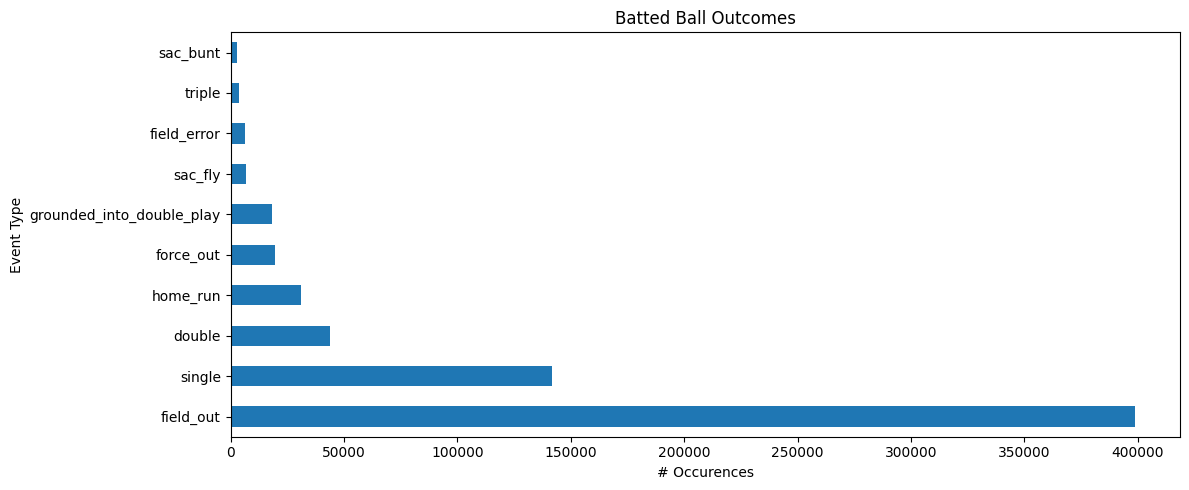

In [15]:
print("Outcome distribution:")
print(batted['events'].value_counts())

plt.figure(figsize=(12,5))
batted["events"].value_counts().head(10).plot(kind="barh")
plt.xlabel("# Occurences")
plt.ylabel("Event Type")
plt.title("Batted Ball Outcomes")
plt.tight_layout()
plt.show()

In [16]:
from matplotlib.patches import Arc, Circle, RegularPolygon, Polygon

def draw_baseball_field(ax=None):
    if ax is None:
        ax = plt.gca()

    #infield
    infield = Arc((0, 0),
                  100,
                  100,
                  theta1=45, theta2=135,
                  edgecolor="blue", lw=2)
    ax.add_patch(infield)

    #outfield
    outfield = Arc((0, 0),
                   300,
                   300,
                   theta1=45, theta2=135,
                   edgecolor="black", lw=2)
    ax.add_patch(outfield)

    #foul line
    ax.plot([0,  110],
            [0,  110],
            color="black")
    ax.plot([0, -110],
            [0,  110],
            color="black")


    #home
    home = Polygon([[ 0, -5],
                    [  5, 0],
                    [  5, 5],
                    [  -5,5],
                    [ -5, 0]],
                    closed = True,
                    edgecolor='black', facecolor='white')
    ax.add_patch(home)

    ax.set_aspect("equal")
    ax.set_xlim(-125, 125)
    ax.set_ylim(-10, 200)
    ax.axis("off")

    return ax

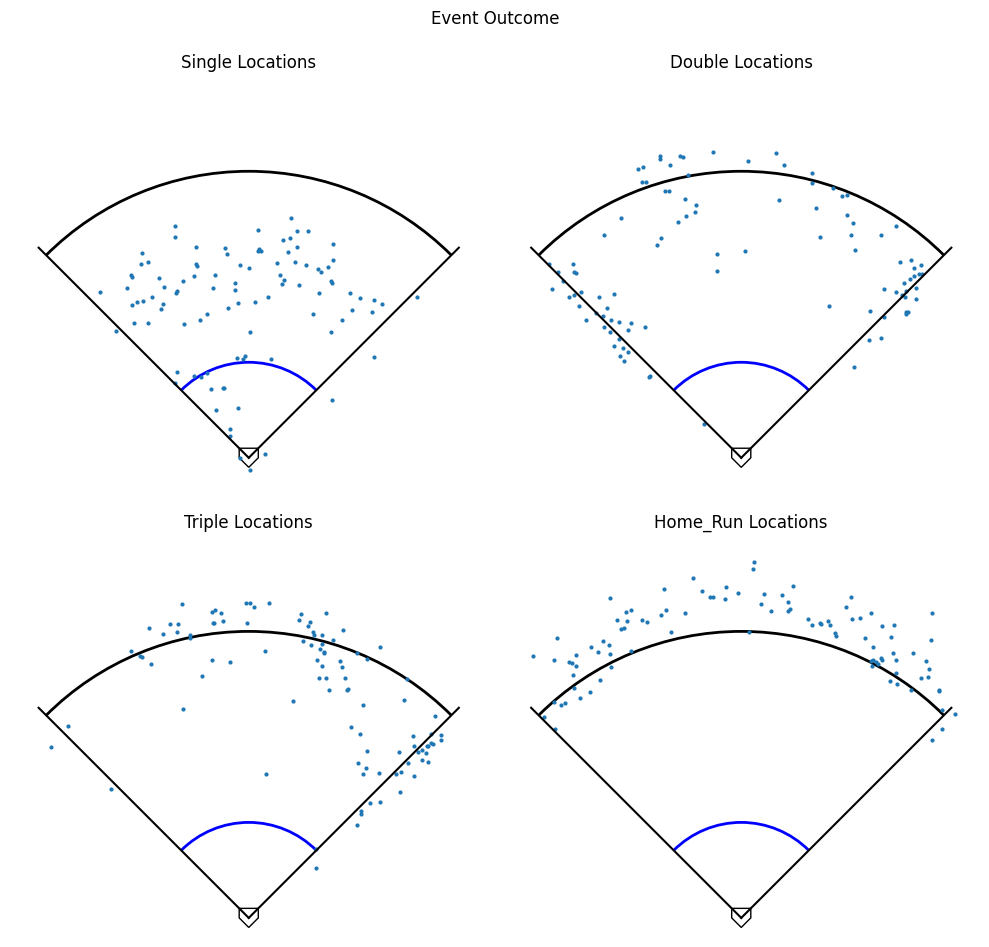

In [17]:
fig, axes = plt.subplots(2,2, figsize = (10,10))
fig.suptitle("Event Outcome")
events = ["single","double","triple","home_run"]

for ax, event in zip(axes.flatten(), events):
  draw_baseball_field(ax)
  sample = batted[batted["events"] == event][["hc_x", "hc_y"]].sample(100, random_state = 42)

  sample["hc_x"] = sample["hc_x"] - 125.42
  sample["hc_y"] = 198.27 - sample["hc_y"]

  ax.scatter(sample["hc_x"], sample["hc_y"], s = 4)


  ax.set_title(f"{event.title()} Locations")
plt.tight_layout()
plt.show()

Training and Modeling
  - Train on year 2021-2024
  - Test on 2025

In [18]:
outcome_map = {
    'single': 1,
    'double': 2,
    'triple': 3,
    'home_run': 4,
    'field_out': 0,
    'force_out': 0,
    'grounded_into_double_play': 0,
    'double_play': 0,
    'fielders_choice_out': 0,
    'sac_fly': 0,
    'sac_bunt': 0,
    'field_error': 1
}

#assign each hit to number
batted["events"] = batted["events"].map(outcome_map).fillna(0).astype(int)
batted["hc_x"] = batted["hc_x"] - 125.42
batted["hc_y"] = 198.27 - batted["hc_y"]

train_df = batted[batted["year"] < 2025].copy()
test_df = batted[batted["year"] == 2025].copy()

print(f"training set row {train_df.shape[0]} rows, test set row {test_df.shape[0]}")

training set row 543376 rows, test set row 134748


Balanced outcome distribution:
events
0    226337
1    147960
2     43720
4     30918
3      3739
Name: count, dtype: int64


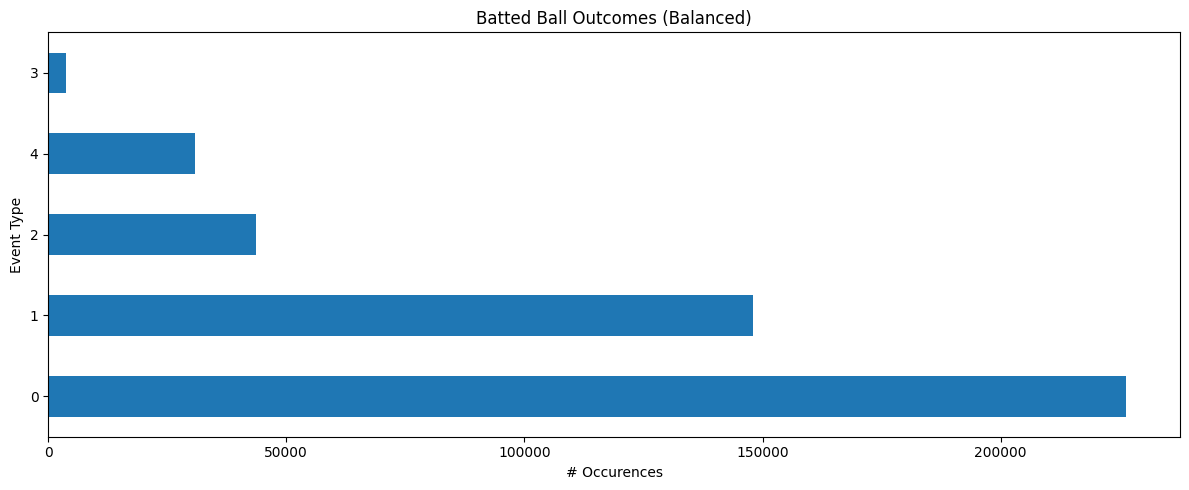

In [19]:
#resample by downsampling majority
resample_min = batted[batted["events"] != 0]
resample_maj = batted[batted["events"] == 0]
downsample_maj = resample(resample_maj, replace = False,n_samples = len(resample_min), random_state = 42)

balanced = pd.concat([resample_min, downsample_maj])

print("Balanced outcome distribution:")
print(balanced['events'].value_counts())

plt.figure(figsize=(12,5))
balanced["events"].value_counts().head(10).plot(kind="barh")
plt.xlabel("# Occurences")
plt.ylabel("Event Type")
plt.title("Batted Ball Outcomes (Balanced)")
plt.tight_layout()
plt.show()

In [20]:
num_features = [
    'launch_speed', 'launch_angle', 'spray_angle',
    'balls', 'strikes', 'outs_when_up', 'bat_speed',
    'hc_x', 'hc_y',
    # Park dimension features
    'LF Line', 'LF Gap', 'CF', 'RF Gap', 'RF Line',
    'Deepest Point', 'Playing Field Area (sq. ft.)',
    'Avg. Fence Distance', 'Avg. Fence Height', 'altitude'
]
bi_features = ["on_1b", "on_2b", "on_3b"]
cat_features = ["stand", "p_throws"]
all_features = num_features + bi_features + cat_features

numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(drop='first', handle_unknown='ignore'))
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features),
        ('bin', binary_transformer, bi_features)
])

In [21]:
y_test_bal = balanced['events']
y_train_bal = balanced['events']
X_test_bal = balanced[all_features]
X_train_bal = balanced[all_features]

y_test = test_df['events']
y_train = train_df['events']
X_test = test_df[all_features]
X_train = train_df[all_features]

Building Models
- Model parameters were chosen using RandomizedSearchCV
- Optimization part is down below

In [22]:
def build_model(type = "random_forest"):
    if type== "random_forest":
        classifier = RandomForestClassifier(
            max_depth = 20,
            n_jobs = -1,
            random_state = 42,
            class_weight = "balanced",
        )
    elif type == "svm":
        classifier = LinearSVC(
            random_state= 42,
            class_weight = "balanced",
            max_iter = 5000,
            penalty = "l2",
            C = 3.593813663804626,
            loss = "squared_hinge"
        )
    elif type == "logistic":
        classifier = LogisticRegression(
            class_weight='balanced',
            multi_class='multinomial',
            random_state = 42
        )
    elif type == "hist_gradient_boosting":
        classifier = HistGradientBoostingClassifier(
            class_weight="balanced",
            random_state = 42,
            early_stopping= True,
            l2_regularization= 0.2,
            min_samples_leaf = 20,
            max_leaf_nodes = 75,
            max_iter = 1500,
            max_depth = 15,
            learning_rate = 0.05
        )
    elif type == "xgb":
        classifier = XGBClassifier(
            objective = "multi:softprob",
            eval_metric = "mlogloss",
            tree_method = "hist",
            random_state = 42,
            n_jobs = -1,
            reg_lambda = 0.8,
            n_estimators = 1200,
            min_chiled_weight = 3,
            max_depth = 12,
            learning_rate = 0.01,
            gamma = 0.5,
            colsample_bytree = 0.8,
            verbose = 0
        )
    elif type == "lgbm":
        classifier = LGBMClassifier(
            objective = "multiclass",
            class_weight = "balanced",
            verbose = -1,
            random_state = 42,
            n_jobs = -1,
            reg_lambda = 2,
            num_leaves = 128,
            n_estimators= 1500,
            min_child_samples = 100,
            max_depth = -1,
            learning_rate = 0.07333,
            colsample_bytree = 1
        )
    else:
        raise ValueError("Model not valid")
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])
    return model

Optimization
- Using RandomSearchSV to apply fixed number of random combinations. We chose this over GridSearchSV due to time constraints.
- Even with RandomSearchSV, each optimization process took over 1hr using only 40% data points.
- F1 scoring was used for scoring

In [23]:
#train on
X_sample, _, y_sample, _ = train_test_split(X_train, y_train, test_size=0.4, random_state=42)

SVM Optimization

In [ ]:
"""
param_dist_svm = {
    "classifier__C": np.logspace(-3, 1, 10),  # 0.001 to 100
    "classifier__loss": ["hinge", "squared_hinge"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__max_iter": [3000, 5000, 8000, 12000]
}
svm = build_model("svm")
search = RandomizedSearchCV(
    svm,
    param_distributions=param_dist_svm,
    n_iter=40,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42,
    scoring="f1_macro"
)
search.fit(X_sample, y_sample)
print(search.best_params_)
"""
print("""{'classifier__penalty': 'l2',
 'classifier__max_iter': 5000,
 'classifier__loss': 'squared_hinge',
 'classifier__class_weight': 'balanced',
 'classifier__C': np.float64(3.593813663804626)""")

HistGradientBoostingClassifier Optimization

In [ ]:
"""param_dist_hgb = {
    "classifier__learning_rate": np.linspace(0.01, 0.1, 5),
    "classifier__max_iter": [500, 1000, 1500, 2000],
    "classifier__max_depth": [None, 6, 10, 15],
    "classifier__max_leaf_nodes": [31, 50, 75],
    "classifier__min_samples_leaf": [20, 50, 100],
    "classifier__l2_regularization": np.linspace(0, 1, 6)
}

hgb = build_model("hist_gradient_boosting")
search = RandomizedSearchCV(
    hgb,
    param_dist_hgb,
    n_iter = 50,
    scoring = "f1_macro",
    cv = 3,
    verbose = 1,
    n_jobs= -1
)

search.fit(X_sample, y_sample)
print(search.best_params_, search.best_score_)"""

#output from search
print("""classifier__min_samples_leaf: 20,
classifier__max_leaf_nodes: 75,
classifier__max_iter: 1500,
classifier__max_depth: 15,
classifier__learning_rate: np.float64(0.0775),
classifier__l2_regularization: 0.2
f1_score: 0.5357676504327996""")

XGBClassifier Optimization

In [ ]:
"""param_dist_xgb = {
    "classifier__n_estimators": [500, 800, 1200, 1500],
    "classifier__learning_rate": np.linspace(0.01, 0.2, 10),
    "classifier__max_depth": [4, 6, 8, 10, 12],
    "classifier__min_child_weight": [1, 3, 5, 7],
    "classifier__subsample": [0.6, 0.8, 1.0],
    "classifier__colsample_bytree": [0.6, 0.8, 1.0],
    "classifier__gamma": [0, 0.1, 0.3, 0.5],
    "classifier__reg_lambda": np.linspace(0, 2, 6)
}
xgb = build_model("xgb")
search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    cv=3,
    verbose=1,
    scoring = "f1_macro"
)
search.fit(X_sample, y_sample)
print(search.best_params_, search.best_score_)
"""
print("""classifier__subsample: 0.8,
classifier__reg_lambda: np.float64(0.8),
classifier__n_estimators: 1200,
classifier__min_child_weight: 3,
classifier__max_depth: 12,
classifier__learning_rate: np.float64(0.01),
classifier__gamma: 0.5,
classifier__colsample_bytree: 0.8
f1_score: 0.5658159707093778""")


LGBMClassifier Optimization

In [ ]:
"""param_dist_lgbm = {
    "classifier__n_estimators": [500, 800, 1200, 1500],
    "classifier__learning_rate": np.linspace(0.01, 0.2, 10),
    "classifier__num_leaves": [30, 60, 128],
    "classifier__max_depth": [-1, 6, 10, 15],
    "classifier__min_child_samples": [20, 50, 100],
    "classifier__subsample": [0.6, 0.8, 1.0],
    "classifier__colsample_bytree": [0.6, 0.8, 1.0],
    "classifier__reg_lambda": np.linspace(0, 2, 6)
}
lgbm = build_model("lgbm")
search_lgbm = RandomizedSearchCV(
    lgbm,
    param_dist_lgbm,
    n_iter=40,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)
search_lgbm.fit(X_sample, y_sample)
print(search_lgbm.best_params_, search_lgbm.best_score_)
"""
print("""classifier__subsample: 1.0
classifier__reg_lambda: np.float64(2.0)
classifier__num_leaves: 128
classifier__n_estimators: 1500
classifier__min_child_samples: 100
classifier__max_depth: -1
classifier__learning_rate': np.float64(0.07333)
classifier__colsample_bytree: 1.0
f1_score: 0.5595751330711084""")

Model Performance
 - Predict on X_test (2025 data)
 - Calculate recall, precision, f1, and support

In [24]:
def model_performance(model, X_test, y_test):

    y_pred = model.predict(X_test)
    #y_prob = model.predict_proba(X_test)
    accuracy = accuracy_score(y_pred, y_test)

    classes = ['Out', 'Single', 'Double', 'Triple', 'Home Run']
    report = classification_report(y_test, y_pred,
            target_names=classes,
            output_dict= True
    )

    confusion = confusion_matrix(y_test, y_pred)
    report = {
        'model': model,
        'accuracy': accuracy,
        'classification_report': pd.DataFrame(report).transpose(),
        'confusion_matrix': confusion,
        'predictions': y_pred,
        #'probabilities': y_prob
    }

    return report

In [25]:
#get model performance with balanced dataset
model_names = ["random_forest", "svm", "logistic", "hist_gradient_boosting", "xgb", "lgbm"]
model_perf_bal = {}
for model in model_names:
  print(f"evaluating {model}")
  mod = build_model(model).fit(X_train_bal, y_train_bal)
  model_perf_bal[model] = model_performance(mod, X_test, y_test)

evaluating random_forest
evaluating svm
evaluating logistic


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


evaluating hist_gradient_boosting
evaluating xgb


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:10:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_chiled_weight", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


evaluating lgbm


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Model Performance on balanced dataset

In [26]:
for model in model_perf_bal.keys():
  print(f"{model} performance")
  display(model_perf_bal[model]["classification_report"])

random_forest performance


,precision,recall,f1-score,support
Out,0.961991,0.927114,0.944231,90196.000000
Single,0.851725,0.878131,0.864726,29384.000000
Double,0.804440,0.943744,0.868542,8408.000000
Triple,0.886889,1.000000,0.940054,690.000000
Home Run,0.881191,0.999506,0.936627,6070.000000
accuracy,0.921105,0.921105,0.921105,0.921105
macro avg,0.877247,0.949699,0.910836,134748.000000
weighted avg,0.924090,0.921105,0.921807,134748.000000


svm performance


,precision,recall,f1-score,support
Out,0.798287,0.709799,0.751447,90196.000000
Single,0.505696,0.271917,0.353665,29384.000000
Double,0.157502,0.160799,0.159134,8408.000000
Triple,0.019394,0.334783,0.036664,690.000000
Home Run,0.274062,0.824217,0.411346,6070.000000
accuracy,0.583289,0.583289,0.583289,0.583289
macro avg,0.350988,0.460303,0.342451,134748.000000
weighted avg,0.666896,0.583289,0.608764,134748.000000


logistic performance


...

,precision,recall,f1-score,support
Out,0.937553,0.865238,0.899945,90196.000000
Single,0.797534,0.757147,0.776816,29384.000000
Double,0.530545,0.632136,0.576902,8408.000000
Triple,0.094021,0.863768,0.169583,690.000000
Home Run,0.789278,0.943493,0.859523,6070.000000
accuracy,0.830639,0.830639,0.830639,0.830639
macro avg,0.629786,0.812356,0.656554,134748.000000
weighted avg,0.870624,0.830639,0.847377,134748.000000


xgb performance


,precision,recall,f1-score,support
Out,0.945355,0.955186,0.950245,90196.000000
Single,0.875417,0.849408,0.862216,29384.000000
Double,0.818182,0.811370,0.814762,8408.000000
Triple,0.996416,0.402899,0.573787,690.000000
Home Run,0.917052,0.979901,0.947435,6070.000000
accuracy,0.921431,0.921431,0.921431,0.921431
macro avg,0.910484,0.799753,0.829689,134748.000000
weighted avg,0.921155,0.921431,0.920541,134748.000000


lgbm performance


,precision,recall,f1-score,support
Out,0.973566,0.932225,0.952447,90196.000000
Single,0.874531,0.912299,0.893016,29384.000000
Double,0.792588,0.997146,0.883177,8408.000000
Triple,0.947802,1.000000,0.973202,690.000000
Home Run,0.945041,1.000000,0.971744,6070.000000
accuracy,0.935331,0.935331,0.935331,0.935331
macro avg,0.906706,0.968334,0.934717,134748.000000
weighted avg,0.939260,0.935331,0.936141,134748.000000


Crossvalidation scoring
- Return dataframe with 5 fold crossvalidation scores on accuracy and F1 scoring

In [27]:
def model_performance_cv(model, X, y, cv = 5):
    skf = StratifiedKFold(n_splits = cv, shuffle = True, random_state = 42)

    f1_macro = cross_val_score(model, X, y, cv = skf, scoring = "f1_macro", n_jobs = -1)
    accuracy = cross_val_score(model, X, y, cv = skf, scoring = "accuracy", n_jobs = -1)

    result = {
        "accuracy_mean": np.mean(accuracy),
        "accuracy_std": np.std(accuracy),
        "f1_macro_mean": np.mean(f1_macro),
        "f1_macro_std": np.std(f1_macro)
    }
    return result

In [28]:
X_train_sample, X_test_sample, y_train_sample, y_test_sample = train_test_split(
    X_train_bal, y_train_bal,
    train_size=10000,
    stratify=y_train_bal,
    random_state=42
)

cv_model_perf_bal = []
for model_name in model_names:
    print(f"Cross validating {model_name}")
    model = model_perf_bal[model_name]["model"]
    result = model_performance_cv(model, X_train_sample, y_train_sample, cv=5)
    result["model_name"] = model_name
    cv_model_perf_bal.append(result)

summary = pd.DataFrame(cv_model_perf_bal)
summary

Cross validating random_forest
Cross validating svm
Cross validating logistic
Cross validating hist_gradient_boosting
Cross validating xgb
Cross validating lgbm


,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,model_name
0,0.7981,0.005054,0.602826,0.006152,random_forest
1,0.5200,0.008792,0.361588,0.008322,svm
2,0.4727,0.011444,0.374644,0.005744,logistic
3,0.7960,0.010766,0.636715,0.011476,hist_gradient_boosting
4,0.8191,0.004684,0.626000,0.002464,xgb
5,0.8079,0.005132,0.624850,0.006316,lgbm


Feature Importance
- For this portion, we picked two highest scoring models XGBoost and LightGBM

In [29]:
xgb = model_perf_bal["xgb"]["model"]
xgb_model = xgb.named_steps["classifier"]
importances_xgb = xgb_model.feature_importances_
feature_names_xgb = xgb.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb
}).sort_values("importance", ascending=False)
importance_df

,feature,importance
1,num__launch_angle,0.211107
8,num__hc_y,0.210859
7,num__hc_x,0.118098
0,num__launch_speed,0.079309
2,num__spray_angle,0.069717
19,cat__stand_R,0.052716
21,bin__on_1b,0.018019
22,bin__on_2b,0.015374
20,cat__p_throws_R,0.014592
16,num__Avg. Fence Distance,0.014566


In [30]:
lgbm = model_perf_bal["lgbm"]["model"]
lgbm_model = lgbm.named_steps["classifier"]
importances_lgbm = lgbm_model.feature_importances_
feature_names_lgbm = lgbm.named_steps["preprocessor"].get_feature_names_out()

importance_df_lgbm = pd.DataFrame({
    "feature": feature_names_lgbm,
    "importance": importances_lgbm
}).sort_values("importance", ascending=False)
importance_df_lgbm

,feature,importance
0,num__launch_speed,132578
8,num__hc_y,121709
7,num__hc_x,100840
1,num__launch_angle,97831
2,num__spray_angle,87308
6,num__bat_speed,56146
15,num__Playing Field Area (sq. ft.),42938
17,num__Avg. Fence Height,39439
3,num__balls,26413
9,num__LF Line,26308


Sensitivity Analysis on features

In [31]:
X_train_transformed = lgbm.named_steps["preprocessor"].transform(X_train_sample.copy())
X_test_transformed = lgbm.named_steps["preprocessor"].transform(X_test_sample.copy())
X_train_transformed = pd.DataFrame(X_train_transformed, columns = feature_names_lgbm)
X_test_transformed = pd.DataFrame(X_test_transformed, columns = feature_names_lgbm)

param = model_perf_bal["lgbm"]["model"].named_steps["classifier"].get_params()

def eval_sens(n = 5):
    top_feats = importance_df_lgbm["feature"].head(n).tolist()

    model = LGBMClassifier(**param)
    model.fit(X_train_transformed[top_feats], y_train_sample)

    pred = model.predict(X_test_transformed[top_feats])
    scoring = f1_score(y_test_sample, pred, average = "macro")
    return scoring

result = {}

for top in [2,4,8, len(feature_names_lgbm)]:
    result[f"Top {top} feature F1 macro score"] = eval_sens(top)

pd.DataFrame(result, index = np.arange(0, 1)).transpose()

,0
Top 2 feature F1 macro score,0.374456
Top 4 feature F1 macro score,0.632027
Top 8 feature F1 macro score,0.636895
Top 24 feature F1 macro score,0.639614


Sensitivity Analysis on number of training data

In [32]:
#sample from balanced training data
def get_sample(n):
    X_sample, _, y_sample, _ = train_test_split(
        X_train_bal,
        y_train_bal,
        train_size=n,
        stratify=y_train_bal,
        random_state=42
    )
    return X_sample, y_sample

param = model_perf_bal["lgbm"]["model"].named_steps["classifier"].get_params()

def eval_sample_sens(n):
    X_sample, y_sample = get_sample(n)

    X_sample_trans = lgbm.named_steps["preprocessor"].transform(X_sample)
    X_test_trans = lgbm.named_steps["preprocessor"].transform(X_test_bal)

    model = LGBMClassifier(**param)
    model.fit(X_sample_trans, y_sample)

    pred = model.predict(X_test_trans)

    return f1_score(y_test_bal, pred, average="macro")

result = {}

for size in [10000, 50000, 100000, 300000]:
    result[f"Train size {size}"] = eval_sample_sens(size)

pd.DataFrame(result, index = np.arange(0, 1)).transpose()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,0
Train size 10000,0.649593
Train size 50000,0.701752
Train size 100000,0.751687
Train size 300000,0.887277


Failure Analysis
- These take some time to run. With limited computational power in Colab, we just attached image of the results from our computer

In [33]:
lgbm = model_perf_bal["lgbm"]["model"]
lgbm_model = lgbm.named_steps["classifier"]
importances_lgbm = lgbm_model.feature_importances_
feature_names_lgbm = lgbm.named_steps["preprocessor"].get_feature_names_out()

y_pred = lgbm.predict(X_test_sample)
y_proba = lgbm.predict_proba(X_test_sample)

results_df = X_test_sample.copy()
results_df["actual"] = y_test_sample.values
results_df["predicted"] = y_pred
results_df["failed"] = results_df["actual"] != results_df["predicted"]
failures = results_df[results_df["failed"]].copy()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


True label: Out
Predicted: Single
Probabilities: {'Out': np.float64(0.48), 'Single': np.float64(0.493), 'Double': np.float64(0.027), 'Triple': np.float64(0.0), 'HR': np.float64(0.0)}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


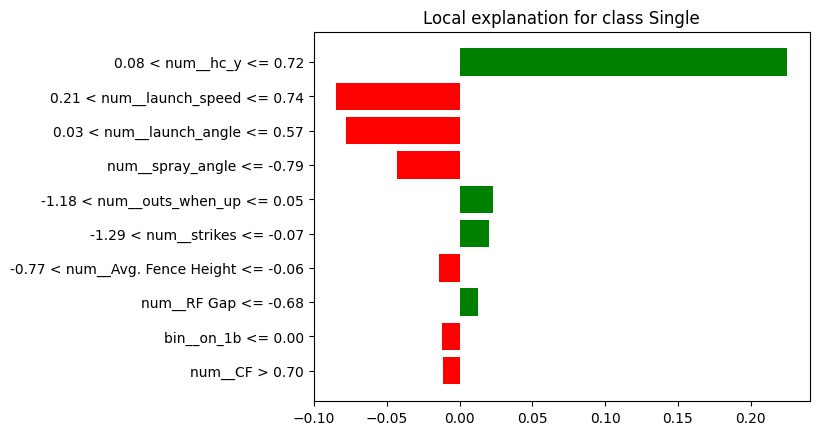

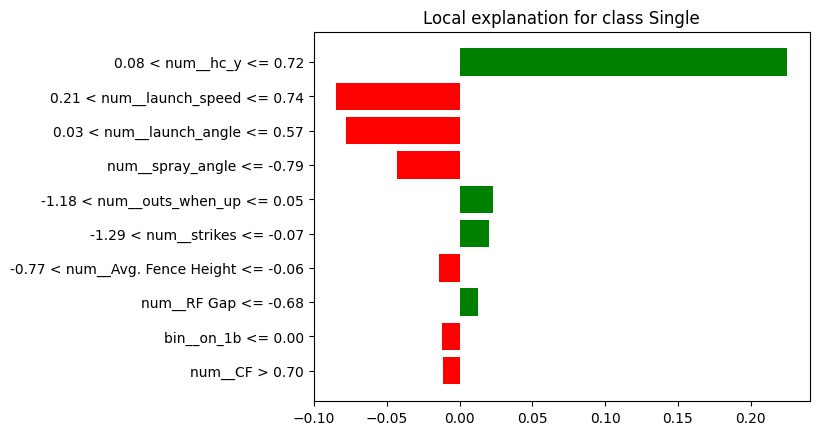

In [34]:
import lime.lime_tabular
model = model_perf_bal["lgbm"]["model"]

preprocessor = model.named_steps["preprocessor"]
classifier   = model.named_steps["classifier"]

X_train_transformed = preprocessor.transform(X_train_sample)
X_test_transformed  = preprocessor.transform(X_test_sample)

feature_names_transformed = preprocessor.get_feature_names_out().tolist()

cat_feats = [
    i for i, name in enumerate(feature_names_transformed)
    if name.startswith("cat__")
]

class_names = ["Out", "Single", "Double", "Triple", "HR"]
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_transformed,
    feature_names= feature_names_transformed,
    class_names = class_names,
    categorical_features = cat_feats,
    mode = "classification",
    discretize_continuous = True
)

#choose failure point. We'll just look at the first failed classification
failure_idx = failures.index[0]
pos_idx = X_test_sample.index.get_loc(failure_idx)
instance = X_test_transformed[pos_idx]

exp = explainer.explain_instance(
    data_row = instance,
    predict_fn= classifier.predict_proba,
    num_features = 10,
    top_labels = 1
)

true_label = class_names[y_test_sample.loc[failure_idx]]
pred_label = class_names[classifier.predict(X_test_transformed[[pos_idx]])[0]]
probs = dict(zip(class_names, classifier.predict_proba(X_test_transformed[[pos_idx]])[0].round(3)))
print(f"True label: {true_label}")
print(f"Predicted: {pred_label}")
print(f"Probabilities: {probs}")
fig=exp.as_pyplot_figure()
fig

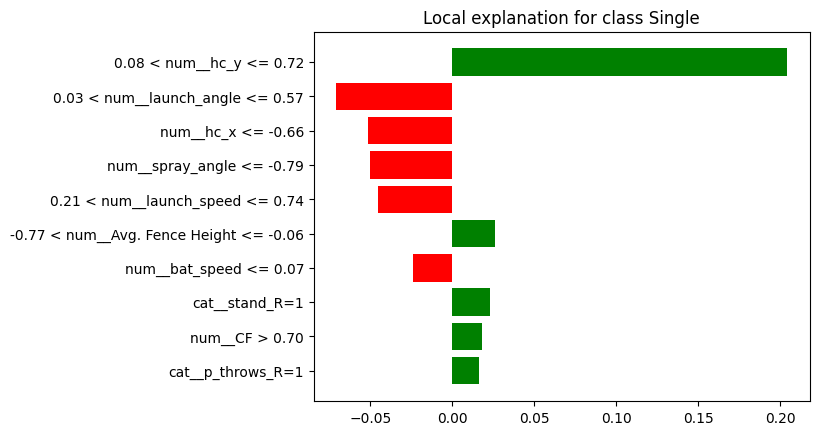

In [ ]:
param_name  = "classifier__num_leaves"
param_range = [1, 16, 32, 64, 128, 256]
cv = 3
scoring = "f1_macro"

#new model
lgbm_model = build_model("lgbm")

train_scores, val_scores = validation_curve(
    lgbm_model,
    X_train_sample, y_train_sample,
    param_name = param_name,
    param_range = param_range,
    cv= cv,
    scoring= scoring,
    n_jobs = -1
)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(param_range))
x_ticks = [str(d) for d in param_range]

ax.plot(x, train_mean, 'o-',  color='blue', label="F1 macro Train")
ax.fill_between(x, train_mean - train_std, train_mean + train_std,
                alpha=0.4, color='steelblue')
ax.plot(x, val_mean,   's--', color='red',    label='F1-macro Validation')
ax.fill_between(x, val_mean - val_std, val_mean + val_std,
                alpha=0.4, color='pink')
ax.set_xticks(list(x))
ax.set_xticklabels(x_ticks)
ax.set_xlabel('num_leaves parameter value', fontsize=12)
ax.set_ylabel('F1-macro score', fontsize=12)
ax.set_title('Validation Curve — LightGBM\n', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

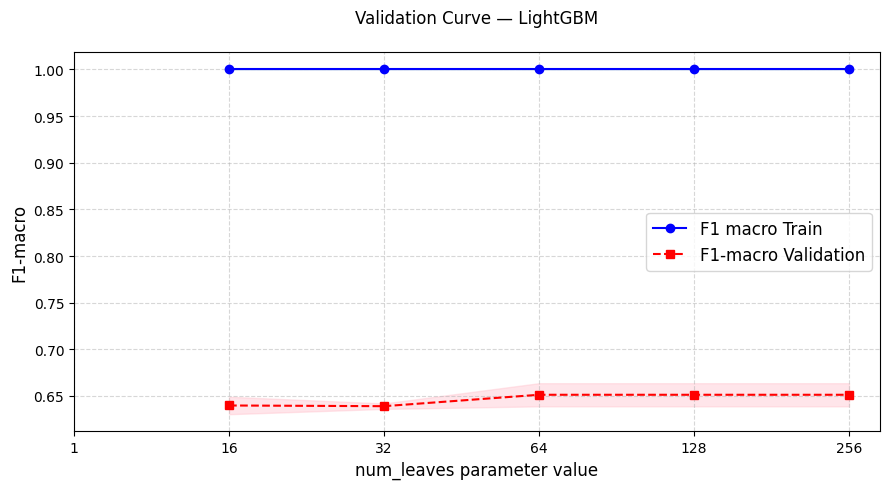

In [ ]:
lgbm_model = model_perf_bal["lgbm"]["model"]
preprocessor = lgbm_model.named_steps["preprocessor"]
classifier = lgbm_model.named_steps["classifier"]
feature_names = feature_names_lgbm
class_names= ["Out", "Single", "Double", "Triple", "HR"]

failed_idx = np.where(results_df["failed"].values)[0][:100]
X_train_transformed = preprocessor.transform(X_train_sample)
X_test_transformed  = preprocessor.transform(X_test_sample)

explainer_shap = shap.TreeExplainer(
    classifier,

    feature_perturbation = "tree_path_dependent"
)

sample_size = 2000
X_sample = X_test_transformed[failed_idx]
shap_val = explainer_shap.shap_values(
    X_sample,
    check_additivity = False
)

fig, axes = plt.subplots(5, 1, figsize=(5, 12))
fig.suptitle("SHAP Summary on Failed Predictions", fontsize=14)
for idx, (ax, cls) in enumerate(zip(axes.flatten(), class_names)):
    plt.sca(ax)
    shap.summary_plot(
        shap_val[:, :, idx], #[n_samples, n_feats, n_classes]
        X_sample,
        feature_names = feature_names,
        plot_type = "dot",
        max_display= 4,
        show = False,
        title = cls,
        plot_size = None,
        color_bar = False
    )
    ax.set_title(cls, fontsize=11)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.set_xlabel("SHAP Val", fontsize = 5)
    ax.set_ylabel("")


plt.subplots_adjust(hspace = 1)
plt.tight_layout()
plt.show()

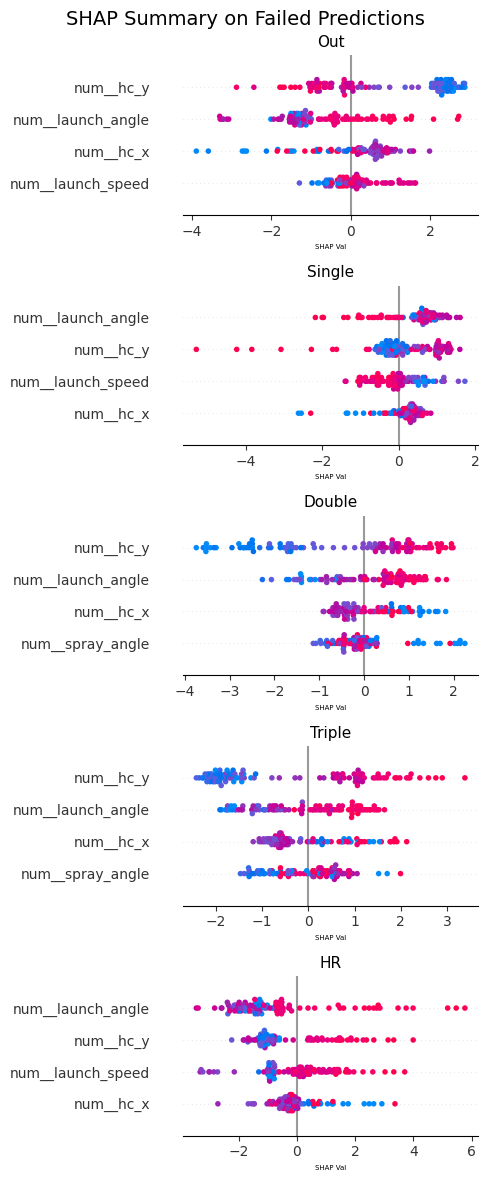

Predicting Player's performance based on park
-Now that we can accurately predict batted ball outcome and how park affects them, we can model how a player would've performed at a certain park

In [ ]:
def get_player_data(batter_name, home_only = True):
    try:
        #get from 2025 data
        #get data only hit from batter's home stadium or every hit
        if home_only == True:
            return test_df[(test_df["batter_name"] == batter_name) &
                            (test_df["batter_team"] == test_df["home_team"])]
        else:
            return test_df[test_df["batter_name"] == batter_name]
    except Exception as e:
        print(f"Error Player not found: {e}")
        return None

In [ ]:
def calculate_player_at_park(model, player_df, park_df):
    park_dim_cols = ['LF Line', 'LF Gap', 'CF', 'RF Gap',
       'RF Line', 'Deepest Point', 'Playing Field Area (sq. ft.)',
       'Avg. Fence Distance', 'Avg. Fence Height', 'altitude']

    results = []

    #add original counts
    results.append({
        "park": "original",
        "out": player_df["events"].value_counts().get(0,0),
        "single": player_df["events"].value_counts().get(1,0),
        "double": player_df["events"].value_counts().get(2,0),
        "triple": player_df["events"].value_counts().get(3,0),
        "hr": player_df["events"].value_counts().get(4,0)
    })

    for idx, park_row in park_df.iterrows():
        park_name = park_row.get("team_name", park_row.get("Team"))

        #create test data with every park's dimensions
        sample_copy = player_df[all_features].copy()
        for col in park_dim_cols:
            if col in park_row.index:
                sample_copy[col] = park_row[col]

        predictions = model.predict(sample_copy)

        counts = pd.Series(predictions).value_counts()

        results.append({
            "park": park_name,
            "out": counts.get(0,0),
            "single": counts.get(1,0),
            "double": counts.get(2,0),
            "triple": counts.get(3,0),
            "hr": counts.get(4,0)
        })

    df = pd.DataFrame(results)

    return df

In [ ]:
#predict how reigning MVP Aaron Judge would've performed had he played at a different park
judge = get_player_data("Aaron Judge", home_only = True)
parks = pf_df.sort_values("Season").groupby("team_name").last().reset_index()
park_aj = calculate_player_at_park(model_perf_bal["xgb"]["model"], judge, parks)

In [ ]:
park_aj

In [ ]:
fig, axes = plt.subplots(2,2, figsize = (10,10))
fig.suptitle("Event Outcome Based on Ballpark")

events = ["single","double","triple","hr"]

for ax, event in zip(axes.flatten(), events):
  ax.barh(park_aj["park"],park_aj[event])

  ax.set_title(f"{event.title()} Counts")
  ax.invert_yaxis()
  ax.set_xticks(np.arange(0,np.max(park_aj[event]) + 5, 10))

plt.tight_layout()
plt.show()